Multipel linjär regression
\begin{equation}
    \mu_{Y|\alpha_1,\alpha_2,\alpha_3} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \beta_3 x_1x_2
\end{equation}

\begin{equation*}
    \mathbf{Y} = X\boldsymbol\beta + \mathbf{E}
\end{equation*}
där $X$ är modellspecifikations matrisen. $\mathbf{E}$ är vektorn med stokastiska fel med avseende på väntevärdet och $\mathbf{Y}$ är en respons vektor för $Y$ över hela stickprovet.

In [1]:
import pandas as pd

data_path = "../Data/"

adv = pd.read_csv(data_path+"Advertising.csv", index_col=0)
adv.head()

,TV,Radio,Newspaper,Sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


<Axes: >

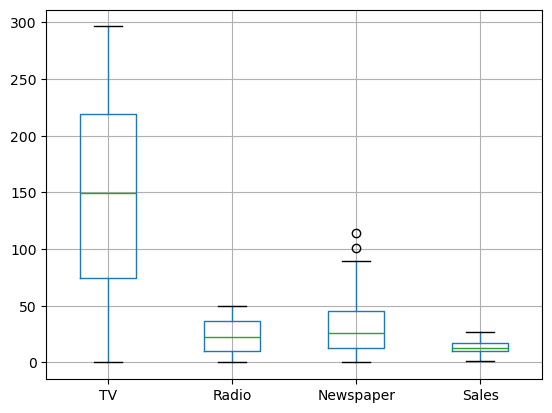

In [2]:
adv.boxplot()

In [3]:
import numpy as np
df = adv
train_fraction = int(len(df)*0.9)
val_fraction = int(train_fraction*0.4)
train = df.sample(n=train_fraction, random_state=42, replace=False)
val = train.sample(n=val_fraction, random_state=42, replace=False)
test = df.drop(train.index)
train = train.drop(val.index)

X_train, y_train = train.drop("Sales", axis="columns"), train["Sales"]
X_val, y_val = val.drop("Sales", axis="columns"), val["Sales"]
X_test, y_test = test.drop("Sales", axis="columns"), test["Sales"]

X_train.insert(0, "Intercept", 1)
X_val.insert(0, "Intercept", 1)
X_test.insert(0, "Intercept", 1)


for dataset in  ["X_train", "X_val", "y_train", "y_val", "X_test", "y_test"]:
    print(f"Shape of {dataset}: {eval(dataset).shape}")


Shape of X_train: (108, 4)
Shape of X_val: (72, 4)
Shape of y_train: (108,)
Shape of y_val: (72,)
Shape of X_test: (20, 4)
Shape of y_test: (20,)


\begin{equation*}
\hat{\mathbf{\beta}} = (X^TX)^{-1}X^TY
\end{equation*}
SSE
\begin{equation}
\sum_{i=1}^n[y_i - (b_0 + b_1 x_{1i} + ... + b_k x_{ki})]²
\end{equation}

In [4]:
b = np.linalg.pinv(X_train.T @ X_train) @ X_train.T @ y_train
k = len(b)-1
n = y_train.shape[0]
SSE = np.sum(np.square(y_train - (X_train @ b)))
var = SSE/(n-k-1)
S = np.sqrt(var)
Syy = (n*np.sum(np.square(y_train)) - np.square(np.sum(y_train)))/n

Sxx = (n*np.sum(np.square(X_train)) - np.square(np.sum(X_train)))/n

SSR = Syy - SSE


ValueError: matrices are not aligned

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(Y_test, X_test @ b)

In [ ]:
b

array([ 6.55588729e+00,  1.97102957e-02,  1.96216023e-02,  1.31056546e-02,
        1.16152252e-03, -5.54550107e-05,  9.06295397e-06, -7.60995596e-07])

In [ ]:
Rsq = SSR/Syy
Rsq
# Choose 90% as confidence level

0.9686440767710514

In [ ]:
import scipy.stats as stats
# H0: all β = 0
sig_statistic = (SSR/k)/var
p_significance = stats.f.sf(sig_statistic, k, n-k-1)
p_significance
# We reject the null-hypothesis, regression IS significant


1.164513841483472e-140

Variance/Co-variance matrix:
\begin{equation*}
c = (X^TX)^{-1}\sigma^2
\end{equation*}

In [ ]:
c = np.linalg.pinv(X_test.T @ X_test)*var

# H0: b3 is irrelevant, β3 = 0
i = 7
b3_statistic = b[i] / (S*np.sqrt(c[i, i]))
p_b3 = 2*min(stats.t.cdf(b3_statistic, n-k-1), stats.t.sf(b3_statistic, n-k-1))
p_b3

0.7647922322525024

In [ ]:
stats.norm.ppf(0.025, 0, 1), stats.norm.isf(0.025, 0, 1)

(-1.9599639845400545, 1.9599639845400545)